# IMDB Movie Review Analysis

**Course:** CS178 - Machine Learning & Data Mining

**Team Members:** My Nguyen, Matthew Lee, Trinh Nguyen

## 1. Summary    

## 2. Data Description

### 2.1. Import and Setup

In [3]:
%pip install --upgrade pyarrow 
%pip install datasets
%pip install datasets-cli
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement datasets-cli (from versions: none)
ERROR: No matching distribution found for datasets-cli


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Classifiers - feel free to add what classifiers you want to use
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,        
    precision_score,        
    recall_score,            
    f1_score,              
    classification_report,   
    confusion_matrix,        
    ConfusionMatrixDisplay, 
    roc_auc_score,          
    roc_curve     
)

# Load the IMDB dataset
# install first: pip install datasets
from datasets import load_dataset

In [ ]:
seed = 1234
np.random.seed(seed) 

In [33]:
# Evaluation
dataset = load_dataset('imdb')
print(dataset)

# Unwrap list object
X_train_raw = list(dataset['train']['text'])
y_train_raw = list(dataset['train']['label'])

X_test_raw = list(dataset['test']['text'])
y_test_raw = list(dataset['test']['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [35]:
info  = dataset['train'].info
features = []

for name, value in dataset['train'].features.items():
    features.append({'name': name, 'value': value})
    
feat_df = pd.DataFrame(features)
display(feat_df)

,name,value
0,text,Value('string')
1,label,"ClassLabel(names=['neg', 'pos'])"


In [37]:
X_train, X_val, y_train, y_val = train_test_split(X_train_raw, y_train_raw, test_size = 0.2, random_state=seed, stratify=y_train_raw)

In [47]:
vectorizer = TfidfVectorizer(   # can be tweaked so the 
    lowercase=True,
    stop_words='english',    
    max_features=25000,       
    ngram_range=(1, 2),       
    min_df=5,                  
    max_df=0.8,
    sublinear_tf=True  # applies (1 + log(tf))
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test_raw)

## 3. Classifiers:
### I. MLP Classifier

In [49]:
hidden_layers_options = [(128,), (64, 32)]
alpha_options = [0.0001, 0.01]
learning_rate_options = [0.001, 0.005]

best_acc = 0
best_params = {}
results_log = []

for layers in hidden_layers_options:
    for alpha_val in alpha_options:
        for lr in learning_rate_options:
            
            print(f"Training -> Layers: {layers} | Alpha: {alpha_val} | LR: {lr}")
            
            mlp = MLPClassifier(
                hidden_layer_sizes=layers,
                alpha=alpha_val,
                learning_rate_init=lr,
                solver='adam',  # faster than sgd for text data
                batch_size=256,
                max_iter=50,
                early_stopping=True,
                random_state=seed
            )
            

            mlp.fit(X_train_tfidf, y_train)
            
            y_pred = mlp.predict(X_val_tfidf)
            acc = accuracy_score(y_val, y_pred)
            
            print(f"Result -> Accuracy: {acc:.4f}\n")
            
            results_log.append({
                'Layers': str(layers), 
                'Alpha': alpha_val, 
                'Learning Rate': lr, 
                'Accuracy': acc
            })
            
            # Update best score if we found a new winner
            if acc > best_acc:
                best_acc = acc
                best_params = {'Layers': layers, 'Alpha': alpha_val, 'LR': lr}
                best_model = mlp 

Training -> Layers: (128,) | Alpha: 0.0001 | LR: 0.001
Result -> Accuracy: 0.8972

Training -> Layers: (128,) | Alpha: 0.0001 | LR: 0.005
Result -> Accuracy: 0.8950

Training -> Layers: (128,) | Alpha: 0.01 | LR: 0.001
Result -> Accuracy: 0.8978

Training -> Layers: (128,) | Alpha: 0.01 | LR: 0.005
Result -> Accuracy: 0.8964

Training -> Layers: (64, 32) | Alpha: 0.0001 | LR: 0.001
Result -> Accuracy: 0.9000

Training -> Layers: (64, 32) | Alpha: 0.0001 | LR: 0.005
Result -> Accuracy: 0.8938

Training -> Layers: (64, 32) | Alpha: 0.01 | LR: 0.001
Result -> Accuracy: 0.9014

Training -> Layers: (64, 32) | Alpha: 0.01 | LR: 0.005
Result -> Accuracy: 0.8916



In [51]:
print(best_acc)
print(best_params)

0.9014
{'Layers': (64, 32), 'Alpha': 0.01, 'LR': 0.001}


In [53]:
filename = 'mlp_model.sav'
pickle.dump(best_model, open(filename, 'wb'))

In [59]:
results_df = pd.DataFrame(results_log)
display(results_df)

,Layers,Alpha,Learning Rate,Accuracy
0,"(128,)",0.0001,0.001,0.8972
1,"(128,)",0.0001,0.005,0.8950
2,"(128,)",0.0100,0.001,0.8978
3,"(128,)",0.0100,0.005,0.8964
4,"(64, 32)",0.0001,0.001,0.9000
5,"(64, 32)",0.0001,0.005,0.8938
6,"(64, 32)",0.0100,0.001,0.9014
7,"(64, 32)",0.0100,0.005,0.8916


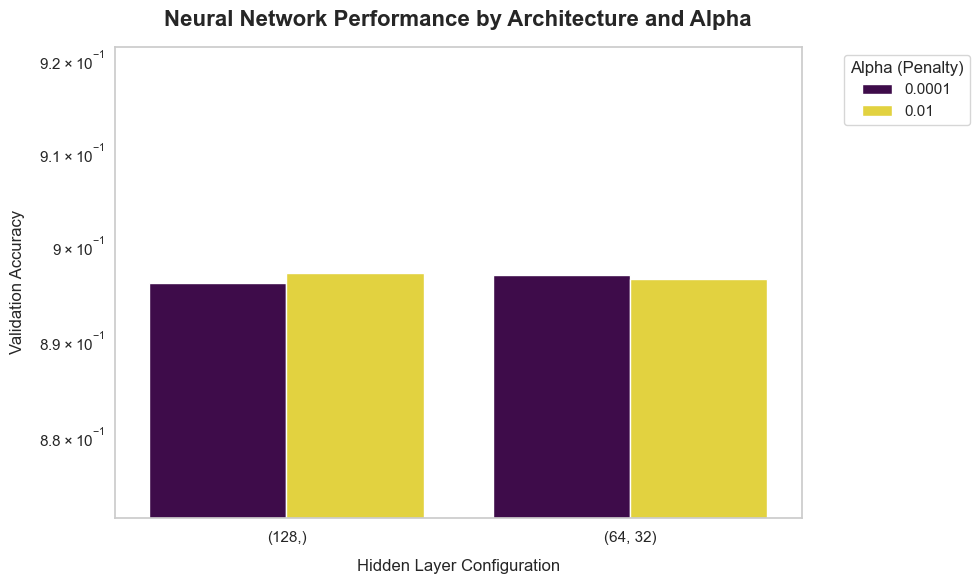

In [76]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df, 
    x='Layers', 
    y='Accuracy', 
    hue='Alpha', 
    palette='viridis',
    errorbar=None
)
min_acc = results_df['Accuracy'].min() - 0.02
max_acc = results_df['Accuracy'].max() + 0.02
plt.ylim(min_acc, max_acc)

plt.title("Neural Network Performance by Architecture and Alpha", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Hidden Layer Configuration", fontsize=12, labelpad=10)
plt.ylabel("Validation Accuracy", fontsize=12, labelpad=10)
plt.yscale('log')
plt.legend(title='Alpha (Penalty)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [73]:
# now predict on test data
y_te_pred = best_model.predict(X_test_tfidf)
acc_te = accuracy_score(y_test_raw, y_te_pred)
print(acc_te)

0.8848


#### Remarks: 
Turning `sublinear_tf` to True in the `TfidfVectorizer` has yielded higher training accuracy, which is most likely due to tf not being scaled linearly, making the number of term repetitions being less significant (non-linearly scaled).

In [78]:
cm_add = confusion_matrix(y_test_raw, y_te_pred)
cm_df_add = pd.DataFrame(cm_add, index=['true_neg', 'true_pos'], columns=['pred_neg', 'pred_pos'])
display(cm_df_add)

NameError: name 'y_test_add' is not defined

### II. Logistic Regression Analysis (Matthew Lee)

In [16]:
# Rebuild clean raw text splits from the dataset object so this section is independent
X_train_text_add = list(dataset['train']['text'])
y_train_add = np.array(dataset['train']['label'])
X_test_text_add = list(dataset['test']['text'])
y_test_add = np.array(dataset['test']['label'])

# Train/validation split from official train split (official test split remains untouched)
X_train_add, X_val_add, y_train_add_split, y_val_add = train_test_split(
    X_train_text_add,
    y_train_add,
    test_size=0.20,
    random_state=seed,
    stratify=y_train_add,
)

vectorizer_add = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50_000,
)

X_train_add_tfidf = vectorizer_add.fit_transform(X_train_add)
X_val_add_tfidf = vectorizer_add.transform(X_val_add)

c_grid = [0.01, 0.1, 1.0, 10.0]
val_rows_add = []
best_c_add = None
best_f1_add = -1.0

for c_val in c_grid:
    model_add = LogisticRegression(
        C=c_val,
        solver='liblinear',
        max_iter=2000,
        random_state=seed,
    )
    model_add.fit(X_train_add_tfidf, y_train_add_split)
    y_val_pred_add = model_add.predict(X_val_add_tfidf)

    precision_add, recall_add, f1_add, _ = precision_recall_fscore_support(
        y_val_add,
        y_val_pred_add,
        average='binary',
        zero_division=0,
    )
    acc_add = accuracy_score(y_val_add, y_val_pred_add)

    val_rows_add.append({
        'C': c_val,
        'val_accuracy': acc_add,
        'val_precision': precision_add,
        'val_recall': recall_add,
        'val_f1': f1_add,
    })

    if f1_add > best_f1_add:
        best_f1_add = f1_add
        best_c_add = c_val

val_results_add = pd.DataFrame(val_rows_add).sort_values('val_f1', ascending=False).reset_index(drop=True)
display(val_results_add)
print(f"Best validation model: C={best_c_add}, F1={best_f1_add:.4f}")


,C,val_accuracy,val_precision,val_recall,val_f1
0,10.00,0.8948,0.888583,0.9028,0.895635
1,1.00,0.8888,0.877916,0.9032,0.890379
2,0.10,0.8542,0.833020,0.8860,0.858694
3,0.01,0.8094,0.791118,0.8408,0.815203


Best validation model: C=10.0, F1=0.8956


,accuracy,precision,recall,f1,selected_C
0,0.8814,0.888518,0.87224,0.880304,10.0


              precision    recall  f1-score   support

    negative     0.8745    0.8906    0.8825     12500
    positive     0.8885    0.8722    0.8803     12500

    accuracy                         0.8814     25000
   macro avg     0.8815    0.8814    0.8814     25000
weighted avg     0.8815    0.8814    0.8814     25000



,pred_neg,pred_pos
true_neg,11132,1368
true_pos,1597,10903


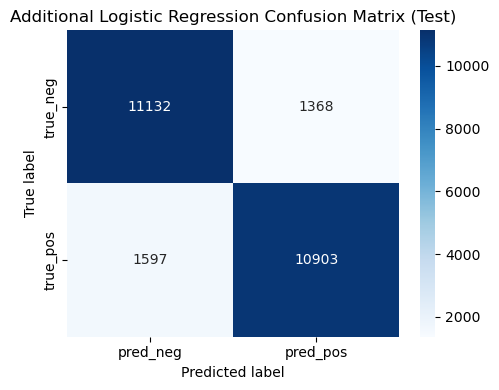

Saved: logistic_regression_imdb.pkl and tfidf_vectorizer_imdb.pkl


In [17]:
# Refit on train+validation with selected C, then evaluate once on official test split
X_trainval_add = X_train_add + X_val_add
y_trainval_add = np.concatenate([y_train_add_split, y_val_add])

vectorizer_final_add = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50_000,
)

X_trainval_add_tfidf = vectorizer_final_add.fit_transform(X_trainval_add)
X_test_add_tfidf = vectorizer_final_add.transform(X_test_text_add)

final_model_add = LogisticRegression(
    C=best_c_add,
    solver='liblinear',
    max_iter=2000,
    random_state=seed,
)
final_model_add.fit(X_trainval_add_tfidf, y_trainval_add)

y_test_pred_add = final_model_add.predict(X_test_add_tfidf)

test_precision_add, test_recall_add, test_f1_add, _ = precision_recall_fscore_support(
    y_test_add,
    y_test_pred_add,
    average='binary',
    zero_division=0,
)
test_accuracy_add = accuracy_score(y_test_add, y_test_pred_add)

test_metrics_add = pd.DataFrame([
    {
        'accuracy': test_accuracy_add,
        'precision': test_precision_add,
        'recall': test_recall_add,
        'f1': test_f1_add,
        'selected_C': best_c_add,
    }
])

display(test_metrics_add)
print(classification_report(y_test_add, y_test_pred_add, target_names=['negative', 'positive'], digits=4))

cm_add = confusion_matrix(y_test_add, y_test_pred_add)
cm_df_add = pd.DataFrame(cm_add, index=['true_neg', 'true_pos'], columns=['pred_neg', 'pred_pos'])
display(cm_df_add)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df_add, annot=True, fmt='d', cmap='Blues')
plt.title('Additional Logistic Regression Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

with open('logistic_regression_imdb.pkl', 'wb') as f:
    pickle.dump(final_model_add, f)
with open('tfidf_vectorizer_imdb.pkl', 'wb') as f:
    pickle.dump(vectorizer_final_add, f)

print('Saved: logistic_regression_imdb.pkl and tfidf_vectorizer_imdb.pkl')


### III: RNN for Text Classification in NLP

In [1]:
# TensorFlow requires Python 3.9-3.12.
# To select the TensorFlow kernel: Click "Select Kernel" (top-right) →
#   "Python Environments" → "Python 3.11.x ('tf_py311': conda)"
#   OR "Jupyter Kernel" → "tf_py311"
# If not listed: Cmd+Shift+P → "Python: Select Interpreter" → /Users/anaconda3/envs/tf_py311/bin/python
import sys
print(f"Python: {sys.version.split()[0]}")
try:
    import tensorflow as tf
    print(f"TensorFlow: {tf.__version__} ✓")
except ImportError:
    print("Select kernel: tf_py311 or Python 3.11 (tf_py311 conda)")

Python: 3.11.15
TensorFlow: 2.21.0 ✓


/Users/anaconda3/envs/tf_py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 100%|██████████| 1/1 [00:03<00:00,  3.34s/ url]
I0000 00:00:1773466260.058535 28696724 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Dataset imdb_reviews downloaded and prepared to /Users/meo/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 231ms/step - accuracy: 0.7939 - loss: 0.4321 - val_accuracy: 0.8742 - val_loss: 0.2944
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 251ms/step - accuracy: 0.9021 - loss: 0.2544 - val_accuracy: 0.9178 - val_loss: 0.2122
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.9335 - loss: 0.1805 - val_accuracy: 0.9526 - val_loss: 0.1524
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 247ms/step - accuracy: 0.9559 - loss: 0.1259 - val_accuracy: 0.9632 - val_loss: 0.1032
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.9729 - loss: 0.0829 - val_accuracy: 0.9710 - val_loss: 0.0947
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 236ms/step - accuracy: 0.9773 - loss: 0.0681 - val_accuracy: 0.9772 - val_loss: 0.0675
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9844 - loss: 0.0477 - val_accuracy: 0.9844 - val_loss: 0.0527
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 258ms/step - accuracy: 0.9892 - loss: 0

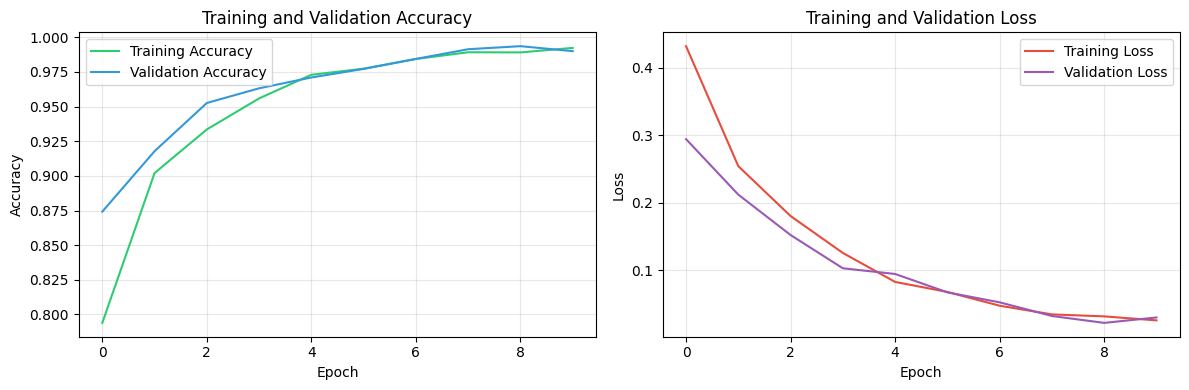

Model saved as rnn_imdb_model.keras


In [6]:
# import libraries
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

# Load IMDB dataset from TensorFlow Datasets
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_ds, test_ds = dataset['train'], dataset['test']

# Shuffle and create validation split from training
BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 10000
MAX_SEQ_LENGTH = 256
EMBEDDING_DIM = 128
RNN_UNITS = 64
EPOCHS = 10

train_ds_full = dataset['train'].shuffle(BUFFER_SIZE)
val_size = int(0.2 * 25000)
val_ds = train_ds_full.take(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_ds = train_ds_full.skip(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = dataset['test'].batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Text vectorization layer
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_SEQ_LENGTH,
    standardize='lower_and_strip_punctuation',
    split='whitespace'
)
train_text = dataset['train'].map(lambda x, y: x)
encoder.adapt(train_text)

# Build RNN model (Bidirectional LSTM)
def build_rnn_model():
    model = tf.keras.Sequential([
        encoder,
        tf.keras.layers.Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM, mask_zero=True),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(RNN_UNITS)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

# Train the model
history = rnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

# Plot training and validation accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#3498db')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss', color='#e74c3c')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#9b59b6')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the trained model for testing
rnn_model.save('rnn_imdb_model.keras')
print('Model saved as rnn_imdb_model.keras')


391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.8401 - loss: 0.8700

Test Loss: 0.8700
Test Accuracy: 0.8401
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.79      0.83     12500
    Positive       0.81      0.89      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000

Accuracy:  0.8401
Precision: 0.8093
Recall:    0.8900
F1 Score:  0.8477


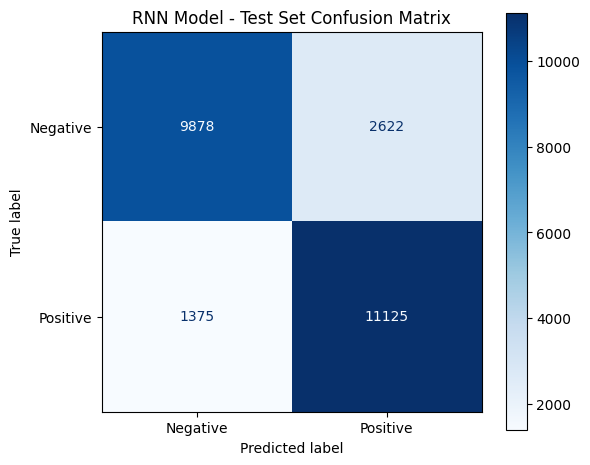

In [7]:
# Test the trained RNN model on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load model if running this cell separately (e.g., after kernel restart)
# rnn_model = tf.keras.models.load_model('rnn_imdb_model.keras')

# Evaluate on test set
test_loss, test_accuracy = rnn_model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Get predictions and true labels
y_pred_proba = rnn_model.predict(test_ds, verbose=1)
# Recreate test_ds for labels (predict consumes the dataset)
test_ds_labels = dataset['test'].batch(BATCH_SIZE)
y_true = np.concatenate([y.numpy() for _, y in test_ds_labels], axis=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Classification metrics
print('\n--- Classification Report ---')
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
print(f'Precision: {precision_score(y_true, y_pred):.4f}')
print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_true, y_pred):.4f}')

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('RNN Model - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

### 8.1 Additional Notes

- Validation tuning metric: F1 score.
- Final evaluation metric set: accuracy, precision, recall, F1, and confusion matrix.
